In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### DATA CHECK to Perform

1. check missing values
2. check Duplicates
3. Check data type
4. check the number of unique of each column
5. check statistics of data set
6. check various categories present in the different categorical coulmn

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [6]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

##### No duplicates values

### Check the number of Unique valuesof each coulmn

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
## statisics Of datasets
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


🔹 print("text", end=" ")

The end parameter in the print() function decides what should be printed at the end of the line.

Normally, print() ends with a newline character (\n)

But end=" " changes it to a space instead

In [11]:
print("categorical in 'gender' variables:      ",end=" ")
print(df['gender'].unique())

print("categorical in 'race/ethnicity' variables:      ",end=" ")
print(df['race/ethnicity'].unique())

print("categorical in 'parental level of education' variables:      ",end=" ")
print(df['parental level of education'].unique())


print("categorical in 'lunch' variables:      ",end=" ")
print(df['lunch'].unique())

print("categorical in 'test preparation course' variables:      ",end=" ")
print(df['test preparation course'].unique())



categorical in 'gender' variables:       ['female' 'male']
categorical in 'race/ethnicity' variables:       ['group B' 'group C' 'group A' 'group D' 'group E']
categorical in 'parental level of education' variables:       ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categorical in 'lunch' variables:       ['standard' 'free/reduced']
categorical in 'test preparation course' variables:       ['none' 'completed']


In [12]:
## Define Numeric and Categorical columns

numeric_fetures=[feature for feature in df.columns if df[feature].dtype!='O']
print('We have {} Numeric features : {}'.format(len(numeric_fetures),numeric_fetures))

categorical_fetures=[feature for feature in df.columns if df[feature].dtype=='O']
print('We have {} Categorical features : {}'.format(len(categorical_fetures),categorical_fetures))

We have 3 Numeric features : ['math score', 'reading score', 'writing score']
We have 5 Categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### FEATURE Engineering-
- adding coulmns for "Total score" and "Average".

In [13]:
df['Total_Score']=df['math score']+df['reading score']+df['writing score']
df['Average_Score']=df['Total_Score']/3
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full_score=df[df['reading score']==100]['Total_Score'].count()
print('Number of students who got full score in reading :',reading_full_score)

math_full_score=df[df['math score']==100]['Total_Score'].count()
print('Number of students who got full score in math :',math_full_score)

writing_full_score=df[df['writing score']==100]['Total_Score'].count()
print('Number of students who got full score in writing :',writing_full_score)

Number of students who got full score in reading : 17
Number of students who got full score in math : 7
Number of students who got full score in writing : 14


In [15]:
reading_full_score=df[df['reading score']<=30]['Total_Score'].count()
print('Number of students who got full score in reading :',reading_full_score)

math_full_score=df[df['math score']<=30]['Total_Score'].count()
print('Number of students who got full score in math :',math_full_score)

writing_full_score=df[df['writing score']<=30]['Total_Score'].count()
print('Number of students who got full score in writing :',writing_full_score)

Number of students who got full score in reading : 8
Number of students who got full score in math : 16
Number of students who got full score in writing : 10


hue = color separation by category

It tells Seaborn:

“Use different colors for different categories in this column.”

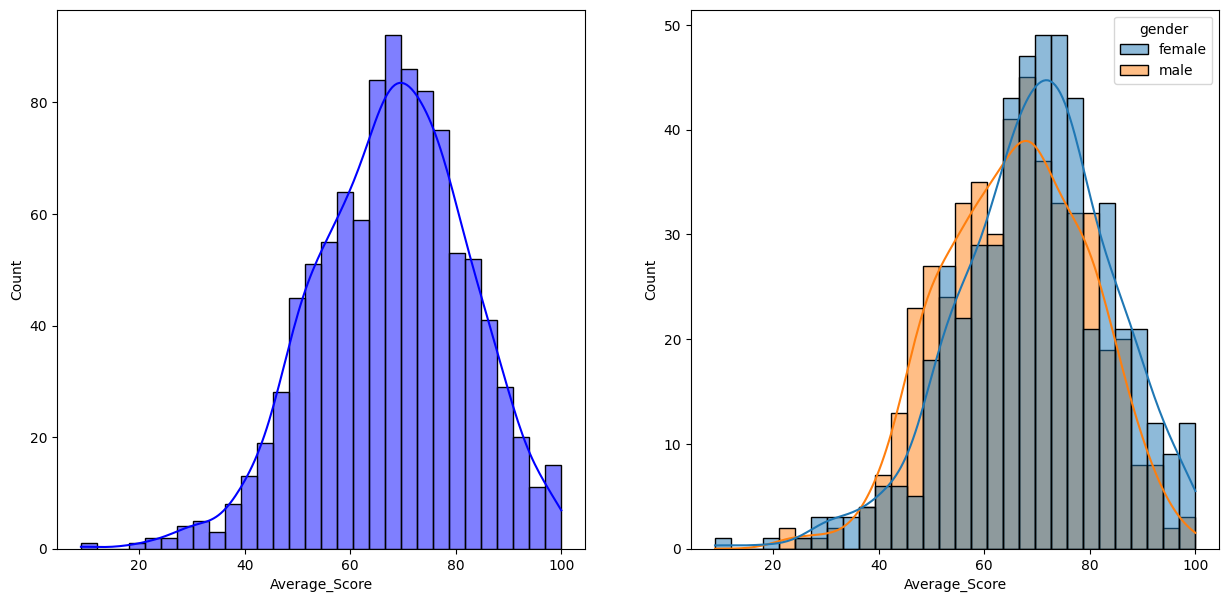

In [16]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,hue='gender')
plt.show()


https://chatgpt.com/share/6933d1fb-b54c-8006-922f-780ed69c7a25

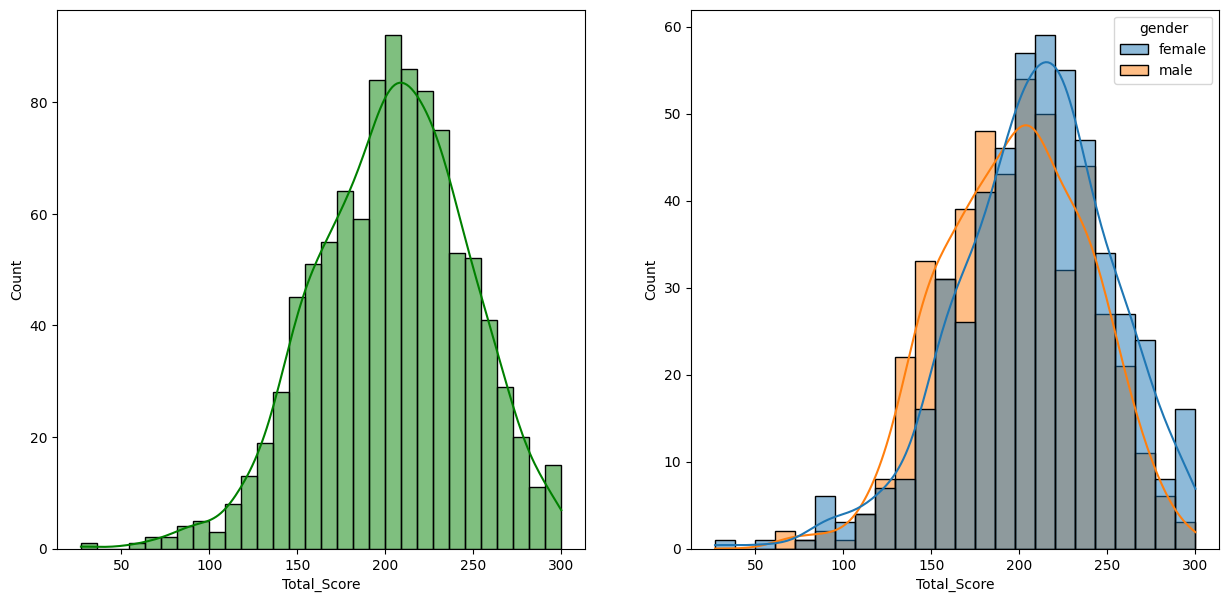

In [17]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total_Score',bins=30,kde=True,color='green')
plt.subplot(122)
sns.histplot(data=df,x='Total_Score',kde=True,hue='gender')
plt.show()

#### Insights
- Female students perform well in exam then male students

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


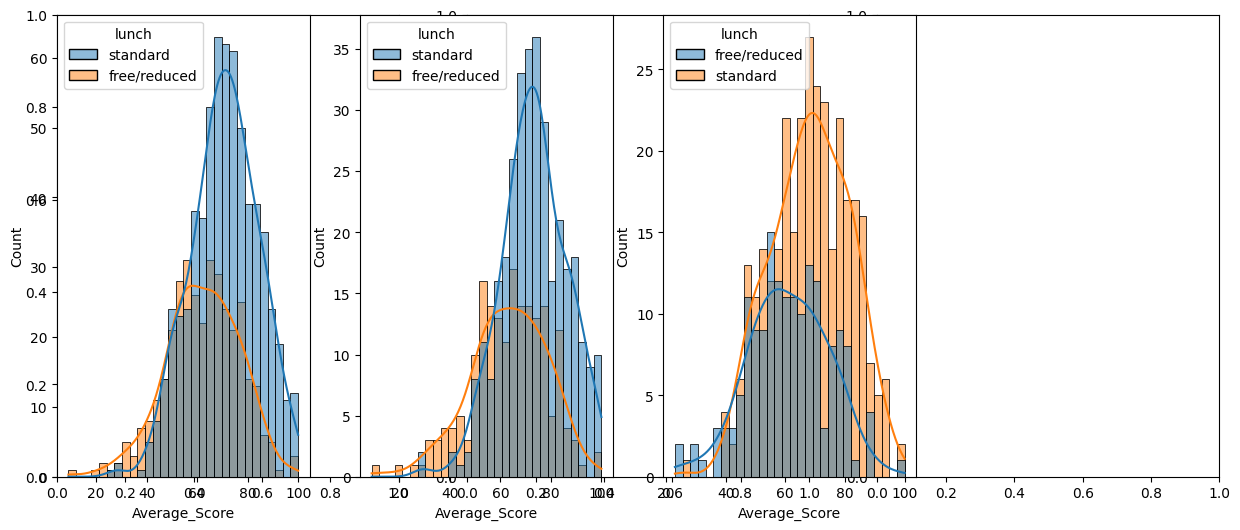

In [19]:
fig1,axs1=plt.subplots(1,3,figsize=(15,6))
plt.subplot(141)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',bins=30,kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',bins=30,kde=True,hue='lunch')
plt.show()


- standard lunch helps perform well in exam
- standard lunch helps perform well in exam be it a male or a female

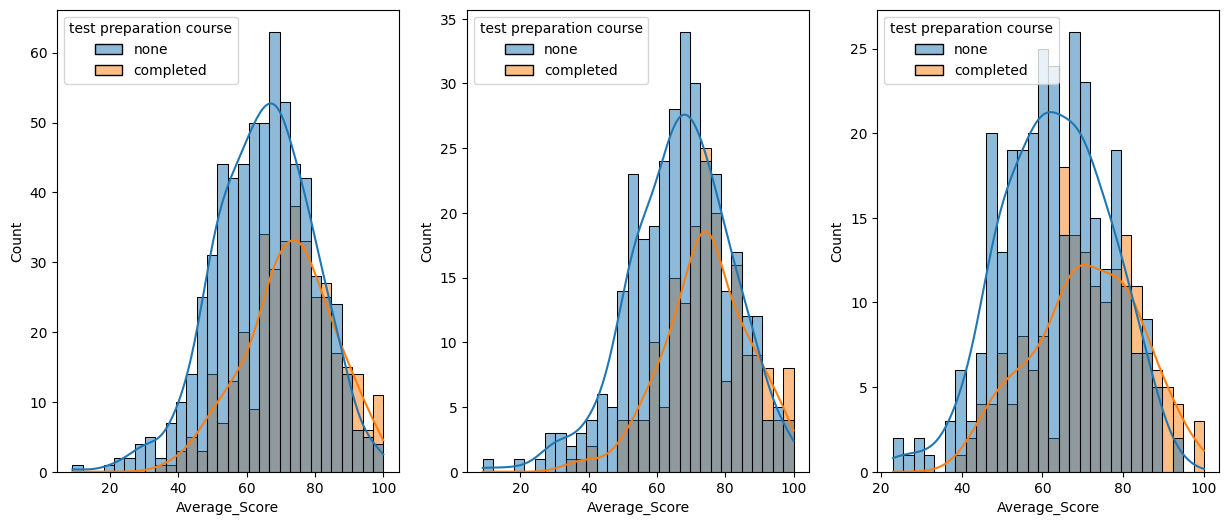

In [20]:
fig2,axs2=plt.subplots(1,3,figsize=(15,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,hue='test preparation course')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',bins=30,kde=True,hue='test preparation course')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',bins=30,kde=True,hue='test preparation course')
plt.show()

⭐ Overall Combined Analysis
🔶 1. Test preparation course improves scores for both genders.

Both male and female students who took the course show higher score peaks.

🔶 2. Improvement tends to be stronger among female students.

Female test-prep students usually shift more to the right (higher average score).

🔶 3. Male scores show more variability.

Greater spread, especially among non-prepared males.

🔶 4. Students without test preparation consistently score lower.

Seen clearly in all 3 plots.

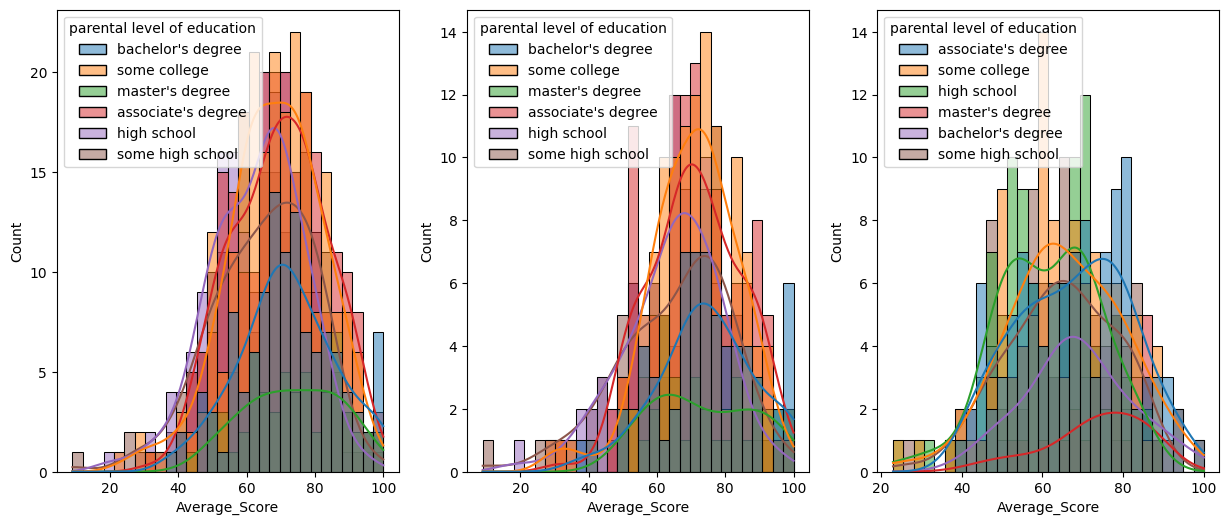

In [21]:
fig3,axes3=plt.subplots(1,3,figsize=(15,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,hue='parental level of education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',bins=30,kde=True,hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',bins=30,kde=True,hue='parental level of education'
)
plt.show()

## Insights
  #### 1st plt-
  - Higher parental education generally increases Average_Score, but the effect is moderate (not extreme).
  #### 2nd plot-
  - Female students show stronger improvement when parents have higher education.
  #### 3rd plot-
  - Males show more variability; parental education helps, but the effect is weaker than in females.

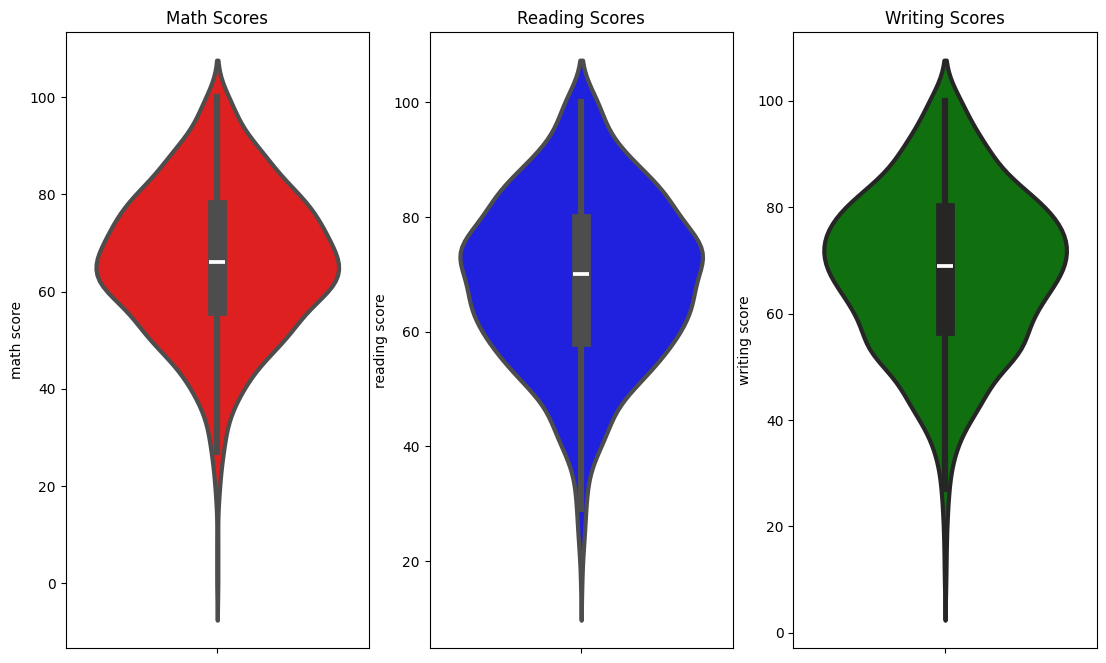

In [22]:
plt.figure(figsize=(18,8))
plt.subplot(141)
plt.title('Math Scores')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(142)
plt.title('Reading Scores')
sns.violinplot(y='reading score',data=df,color='blue',linewidth=3)
plt.subplot(143)
plt.title('Writing Scores')
sns.violinplot(y='writing score',data=df,color='green',linewidth=3)
plt.show()

#### Insights

- from the above three plots in clearly visible that most of the students score between 60-80 in Maths ,Reading and ,Writing most of them score

In [23]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

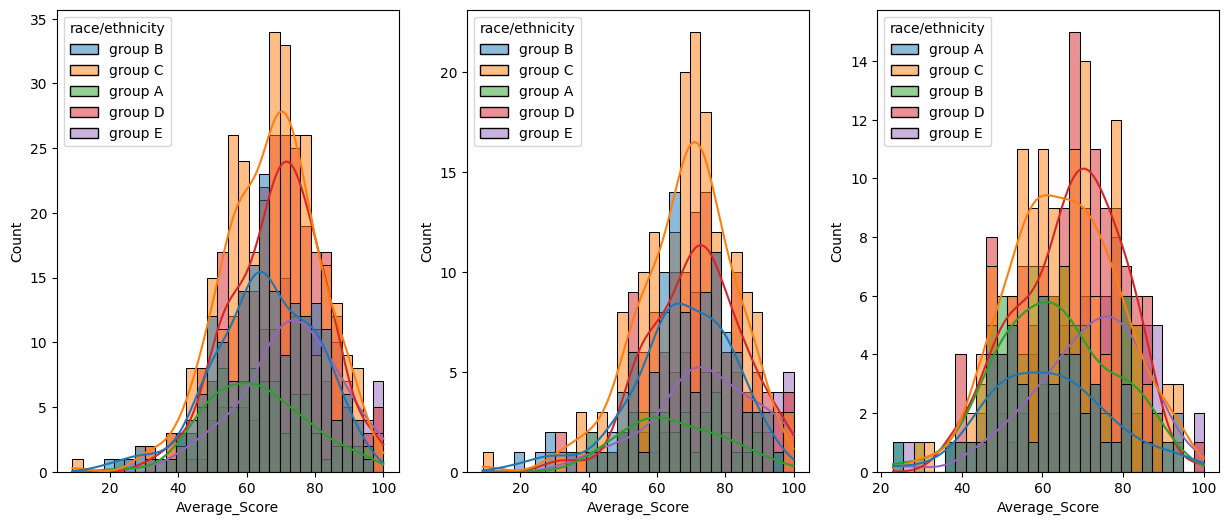

In [24]:

fig4,axs4=plt.subplots(1,3,figsize=(15,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,hue='race/ethnicity')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_Score',bins=30,kde=True,hue='race/ethnicity')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_Score',bins=30,kde=True,hue='race/ethnicity')
plt.show()



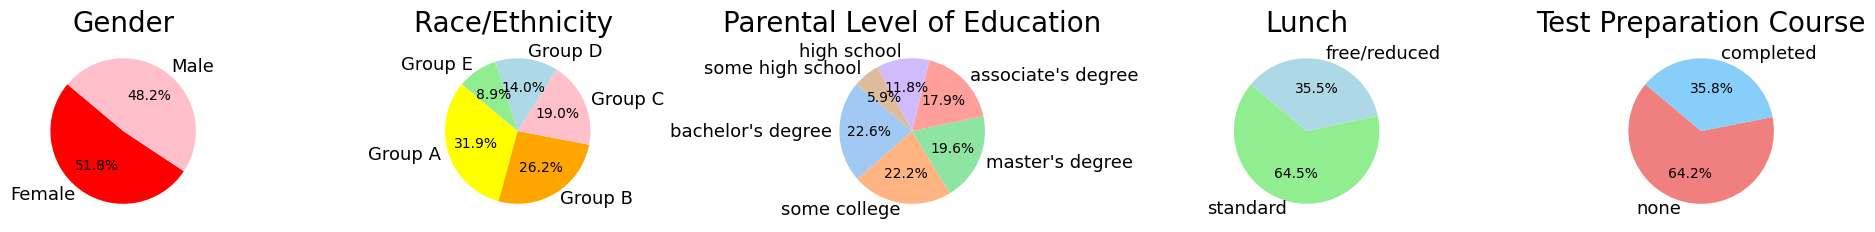

In [33]:
### Multivariate Analysis
plt.rcParams['figure.figsize']=(18,8)

plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels='Female','Male'
color=['red','pink']

plt.pie(size,labels=labels,colors=color,autopct='%1.1f%%',startangle=140)
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=df['race/ethnicity'].value_counts()
lables='Group A','Group B','Group C','Group D','Group E'
color=['yellow','orange','pink','lightblue','lightgreen']
plt.pie(size,labels=lables,colors=color,autopct='%1.1f%%',startangle=140)
plt.title('Race/Ethnicity ',fontsize=20)
plt.axis('off')


plt.subplot(1,5,3)
size=df['parental level of education'].value_counts()
labels=df['parental level of education'].unique()
color=sns.color_palette('pastel')[0:6]
plt.pie(size,labels=labels,colors=color,autopct='%1.1f%%',startangle=140)
plt.title('Parental Level of Education',fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size=df['lunch'].value_counts()
labels=df['lunch'].unique()
color=['lightgreen','lightblue']
plt.pie(size,labels=labels,colors=color,autopct='%1.1f%%',startangle=140)
plt.title('Lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=df['test preparation course'].value_counts()
labels=df['test preparation course'].unique()
color=['lightcoral','lightskyblue'] 
plt.pie(size,labels=labels,colors=color,autopct='%1.1f%%',startangle=140)
plt.title('Test Preparation Course',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid(True)
plt.show()


✅ 5. startangle=140

This rotates the starting point of the pie chart by 140 degrees.

#### Univariate analysis(How is distribution of gender?)




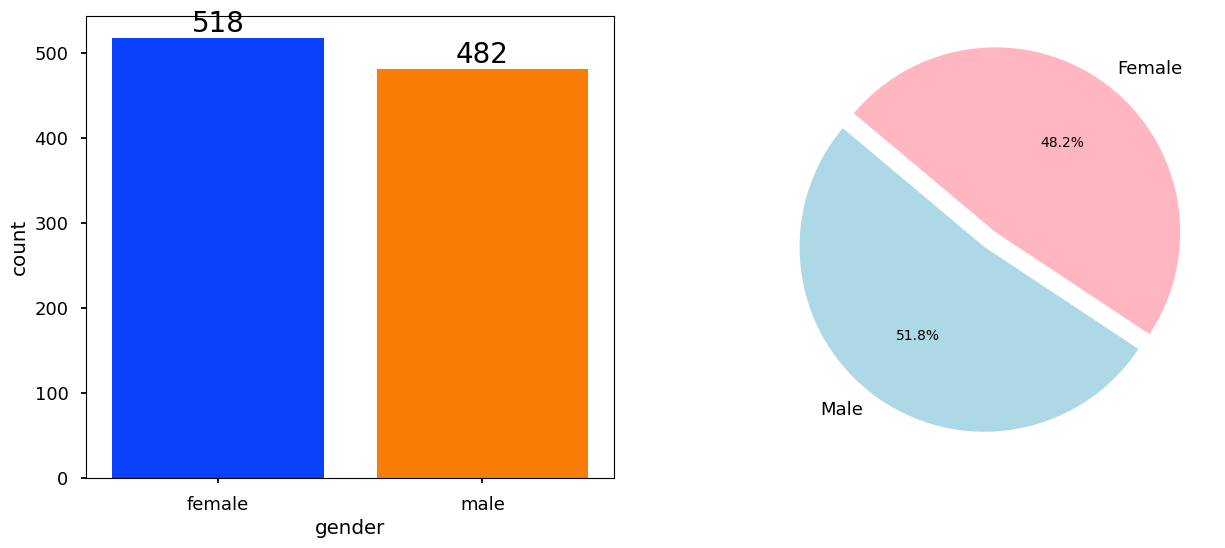

In [34]:
f,ax=plt.subplots(1,2,figsize=(15,6))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',fontsize=20)
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',colors=['lightblue','lightpink'],startangle=140)
plt.show()




#### Insights
- Gender has balanced data with female 518(48.2%),male students 482(51.8%)

#### Bivariate analysis(Is gender has any impact on student's performance?)



In [38]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,Total_Score,Average_Score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


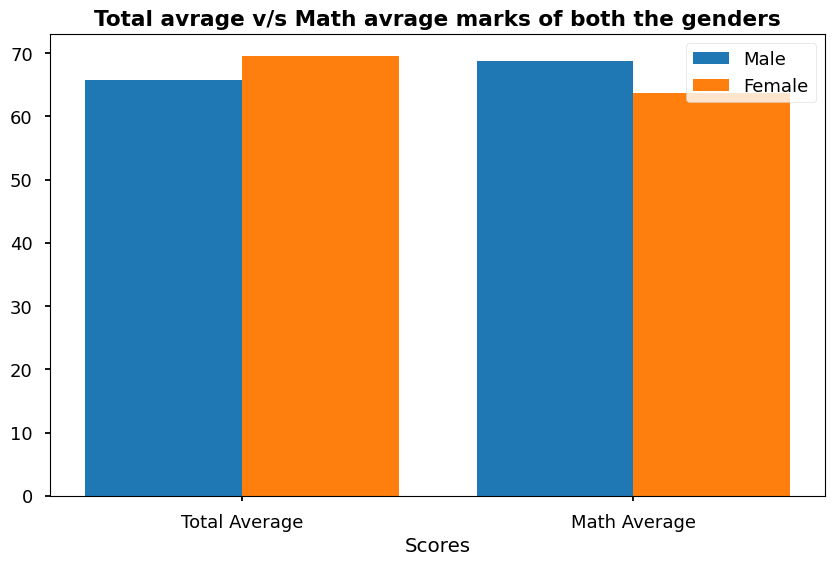

In [40]:
plt.figure(figsize=(10,6))

X=['Total Average','Math Average']

female_scores=[gender_group['Average_Score'][0],gender_group['math score'][0]]
male_scores=[gender_group['Average_Score'][1],gender_group['math score'][1]]

X_axis=np.arange(len(X))

plt.bar(X_axis-0.2,male_scores,0.4,label='Male')
plt.bar(X_axis+0.2,female_scores,0.4,label='Female')

plt.xticks(X_axis,X)
plt.xlabel('Scores')
plt.title("Total avrage v/s Math avrage marks of both the genders",fontweight='bold')
plt.legend()
plt.show()


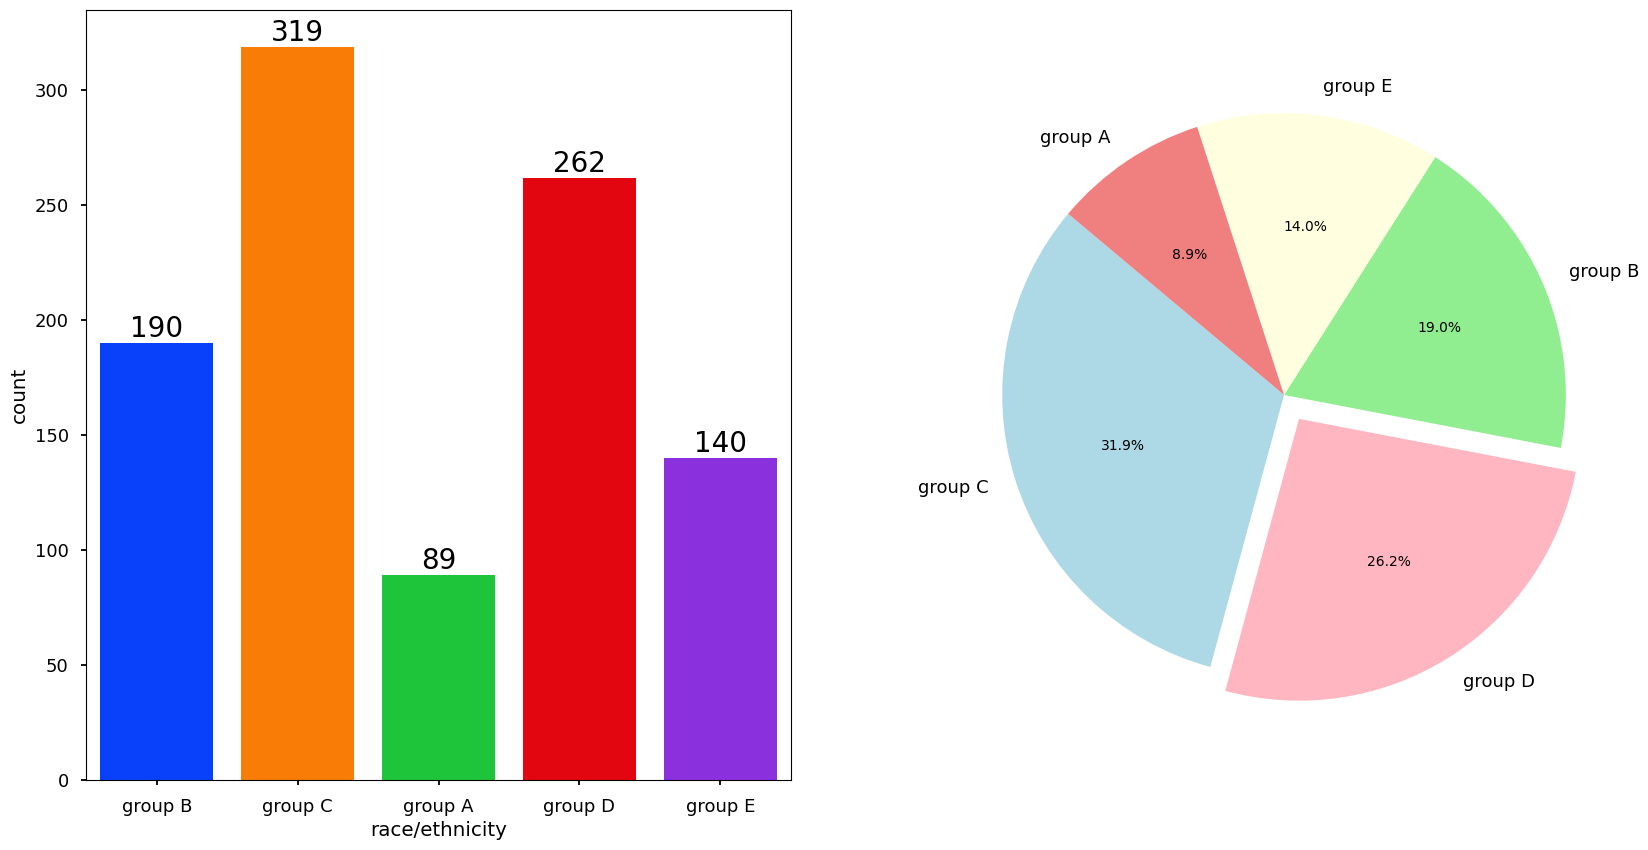

In [41]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',fontsize=20)
plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0,0.1,0,0,0],autopct='%1.1f%%',colors=['lightblue','lightpink','lightgreen','lightyellow','lightcoral'],startangle=140)
plt.show()


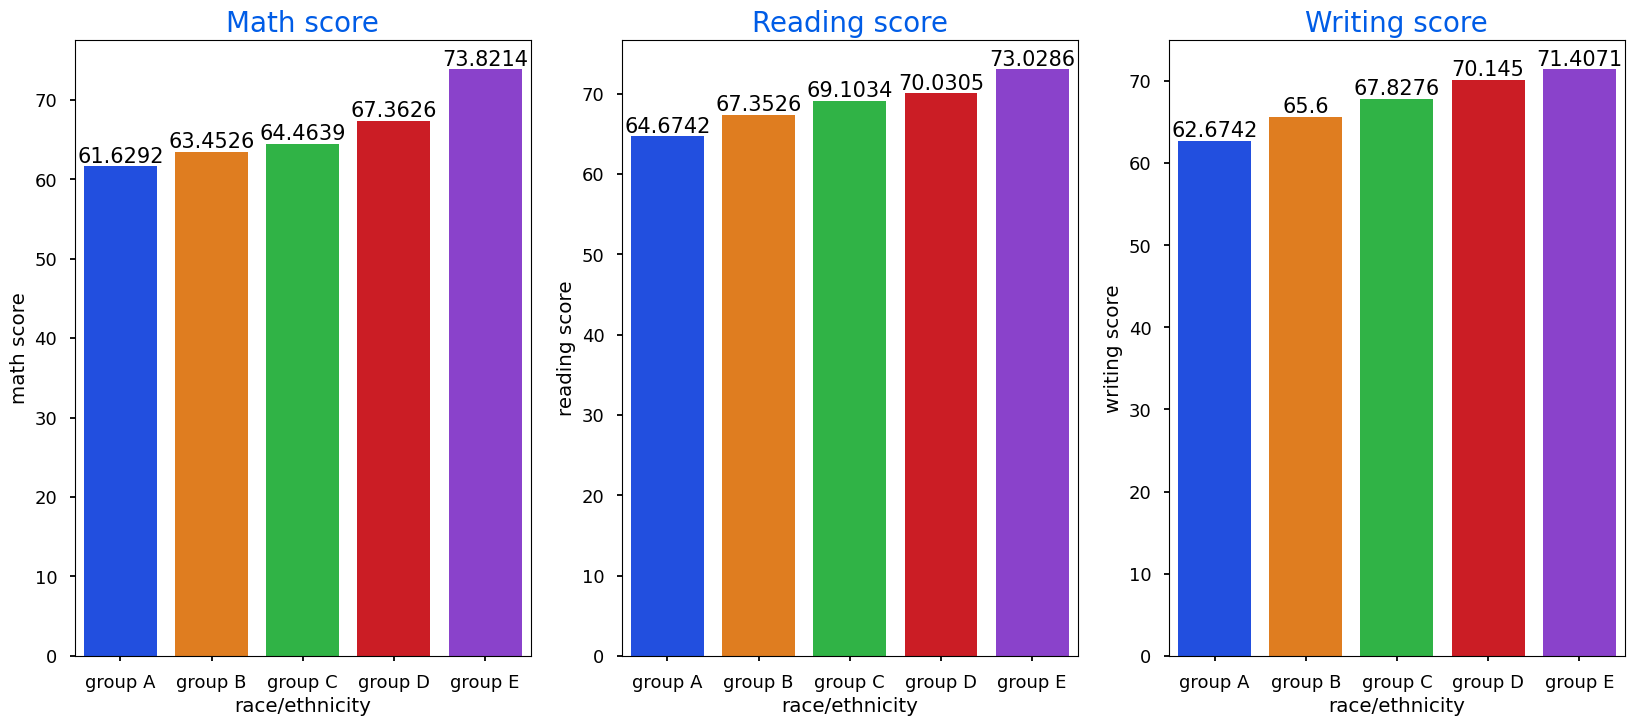

In [42]:
group_data2=df.groupby('race/ethnicity')
group_data2.mean(numeric_only=True)
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=group_data2['math score'].mean(numeric_only=True).index,y=group_data2.mean(numeric_only=True)['math score'],palette='bright',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',fontsize=15)

sns.barplot(x=group_data2['reading score'].mean(numeric_only=True).index,y=group_data2.mean(numeric_only=True)['reading score'],palette='bright',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',fontsize=15)
sns.barplot(x=group_data2['writing score'].mean(numeric_only=True).index,y=group_data2.mean(numeric_only=True)['writing score'],palette='bright',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20 )
for container in ax[2].containers:
    ax[2].bar_label(container,color='black',fontsize=15)
plt.show()
plt.rcParams['figure.figsize']=(18,8)



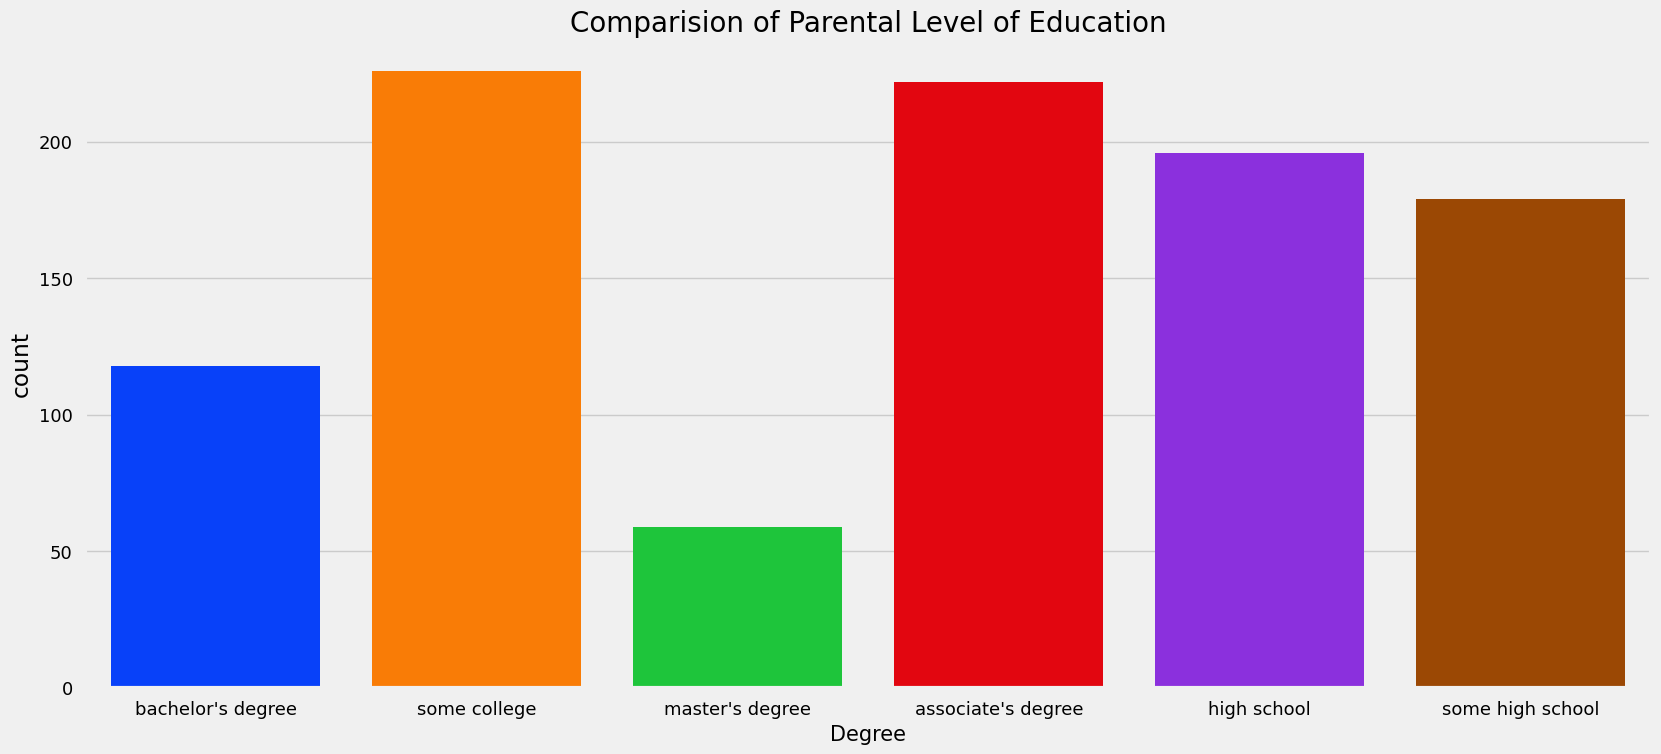

In [44]:
plt.rcParams['figure.figsize']=(18,8)
plt.style.use('fivethirtyeight')
sns.countplot(x=df['parental level of education'],data=df,palette='bright',saturation=0.95)
plt.title('Comparision of Parental Level of Education',fontsize=20)
plt.xlabel('Parental Level of Education',fontsize=15)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()